## VTMM5 — Üç günlük görüntü × **3 ViT** + meta

Her örnek için aynı `station_year` içinde **bugün (d0)**, **d−1**, **d−2** yolları bağlanır; eksik geçmiş günler **bir önceki bilinen** yolla doldurulur (VTMM4 ile aynı mantık).

- **Omurga:** üç ayrı `ViT-B/16` (448), özellik birleştirme + meta MLP + sınıflandırıcı.
- **Test:** İki metrik **ayrı** izlenir: (1) **Fenoloji / seq-dec** — `vtmm4_decode` ile 2 günlük geçiş çözümlemesi; (2) **Sınıflandırma / argmax** — görüntü başına düz doğruluk. Erken durdurma **seq-dec** üzerinden; en iyi argmax epoch’u da loglanır ve isteğe bağlı `.pth` ile saklanabilir.
- Çıktılar: **`vtmm5/`**

Yolları kendi ortamınıza göre güncelleyin.


In [1]:
# --- LIBRARIES ---
import os
import random
import sys

if sys.platform != "win32":
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from PIL import Image
from IPython.display import display

from framework import WheatFramework, generate_group_folds, save_model, run_fold_with_trainer

from vtmm4_decode import decode_labels_for_dataframe, sequential_decode_accuracy


In [2]:
# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


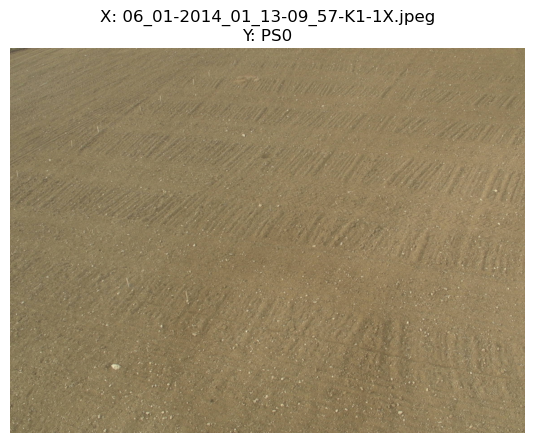

In [3]:
wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[["path", "label"]].head(8))

    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# --- VTMM5: TRIPLE ViT (d0,d-1,d-2) + META + SEQUENTIAL 2-DAY DECODE ---

TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15),
}
DEFAULT_COORD = (39.93, 32.85)


def prepare_advanced_features(df):
    df = df.copy()

    def extract_date(path):
        match = re.search(r"(\d{4}[_-]\d{2}[_-]\d{2})", str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace("-", "_"), format="%Y_%m_%d", errors="coerce")

    df["dt"] = df["path"].apply(extract_date)

    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df["agri_day_of_year"] = df["dt"].apply(get_agricultural_doy)
    df["date_missing"] = df["dt"].isna().astype(np.float32)
    df["plate_code"] = df["station_year"].astype(str).str.extract(r"^(\d{2})")[0].astype(float)

    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]

    coords = df["plate_code"].apply(get_lat_lon)
    df["latitude"] = [c[0] for c in coords]
    df["longitude"] = [c[1] for c in coords]
    return df


def add_three_day_paths(df):
    # path_d0=today, path_d1=t-1, path_d2=t-2; missing past days: carry forward last known path.
    df = df.copy()
    lookups = {}
    for sy, g in df.groupby("station_year", sort=False):
        by_date = {}
        for _, r in g.iterrows():
            d = pd.Timestamp(r["dt"])
            if pd.isna(d):
                continue
            by_date[d.normalize()] = r["path"]
        lookups[sy] = by_date

    p0, p1, p2 = [], [], []
    for _, r in df.iterrows():
        sy = r["station_year"]
        bd = lookups.get(sy, {})
        t = pd.Timestamp(r["dt"])
        if pd.isna(t):
            p0.append(r["path"])
            p1.append(r["path"])
            p2.append(r["path"])
            continue
        tn = t.normalize()
        d0 = bd.get(tn, r["path"])
        d1 = bd.get(tn - pd.Timedelta(days=1), d0)
        d2 = bd.get(tn - pd.Timedelta(days=2), d1)
        p0.append(d0)
        p1.append(d1)
        p2.append(d2)
    df["path_d0"] = p0
    df["path_d1"] = p1
    df["path_d2"] = p2
    return df


def _ensure_min_side(img: Image.Image, min_side: int) -> Image.Image:
    w, h = img.size
    if min(w, h) >= min_side:
        return img
    scale = min_side / min(w, h)
    nw, nh = max(int(round(w * scale)), min_side), max(int(round(h * scale)), min_side)
    return img.resize((nw, nh), Image.BICUBIC)


def _random_square_crop_pil(img: Image.Image, crop_size: int) -> Image.Image:
    img = _ensure_min_side(img, crop_size)
    w, h = img.size
    left = random.randint(0, w - crop_size)
    top = random.randint(0, h - crop_size)
    return img.crop((left, top, left + crop_size, top + crop_size))


class MultimodalTripleDayDataset(Dataset):
    def __init__(self, df, label_map, crop_size, train_transform, eval_transform, is_training=True):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
        self.crop_size = int(crop_size)
        self.train_transform = train_transform
        self.eval_transform = eval_transform
        self.is_training = is_training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        paths = [row["path_d0"], row["path_d1"], row["path_d2"]]
        tensors = []
        for p in paths:
            img = Image.open(p).convert("RGB")
            patch = _random_square_crop_pil(img, self.crop_size)
            if self.is_training:
                if self.train_transform:
                    patch = self.train_transform(patch)
            else:
                if self.eval_transform:
                    patch = self.eval_transform(patch)
            tensors.append(patch)
        img3 = torch.stack(tensors, dim=0)

        agri_day = row["agri_day_of_year"]
        lat_norm = row["latitude"]
        lon_norm = row["longitude"]
        meta_tensor = torch.tensor([agri_day, lat_norm, lon_norm], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row["label"]], dtype=torch.long)
        return img3, meta_tensor, label_tensor


class MultimodalViTTriple(nn.Module):
    # Three separate ViT-B/16 encoders (d0, d-1, d-2) + meta + classifier.

    def __init__(self, num_classes):
        super().__init__()
        from torchvision.models.vision_transformer import interpolate_embeddings

        weights = models.ViT_B_16_Weights.DEFAULT
        vit_num = 3
        self.vit_arr = nn.ModuleList([models.vit_b_16(weights=None, image_size=448) for _ in range(vit_num)])
        state_dict = weights.get_state_dict(progress=True)
        state_dict = interpolate_embeddings(
            image_size=448, patch_size=16, model_state=state_dict, reset_heads=True
        )
        vit_dim = self.vit_arr[0].heads.head.in_features
        for vit in self.vit_arr:
            vit.load_state_dict(state_dict, strict=False)
            vit.heads = nn.Identity()
        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.GELU(),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.38),
            nn.Linear(vit_num * vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.28),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, imgs3, meta):
        # imgs3: (B, 3, C, H, W)
        feats = [self.vit_arr[k](imgs3[:, k]) for k in range(3)]
        v_features = torch.cat(feats, dim=1)
        m_features = self.meta_net(meta)
        combined = torch.cat((v_features, m_features), dim=1)
        return self.classifier(combined)


def _triple_vit_backbone_params(model):
    ps = []
    for vit in model.vit_arr:
        ps += list(vit.parameters())
    return ps


def _triple_vit_head_params(model):
    return list(model.meta_net.parameters()) + list(model.classifier.parameters())


VTMM5_OUT = "vtmm5"
os.makedirs(VTMM5_OUT, exist_ok=True)


def multimodal_triple_vit_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get("img_size", 448)
    freeze_epochs = int(config.get("freeze_epochs", 2))
    base_lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.08)
    label_smoothing = config.get("label_smoothing", 0.08)
    max_grad_norm = float(config.get("max_grad_norm", 1.0))
    unfreeze_lr_mult = float(config.get("unfreeze_lr_mult", 0.5))
    backbone_lr_mult = float(config.get("backbone_lr_mult", 0.1))
    heads_lr_boost = float(config.get("heads_lr_boost", 2.0))

    train_df = add_three_day_paths(train_df)
    test_df = add_three_day_paths(test_df)

    all_labels = sorted(train_df["label"].unique())
    label_map = {label: i for i, label in enumerate(all_labels)}
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)
        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)

    train_transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04)], p=0.55
            ),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.35))], p=0.12),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_ds = MultimodalTripleDayDataset(
        train_df, label_map, img_size, train_transform, eval_transform, is_training=True
    )
    test_ds = MultimodalTripleDayDataset(
        test_df, label_map, img_size, train_transform, eval_transform, is_training=False
    )

    bs = config["batch_size"]
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False)

    model = MultimodalViTTriple(num_classes).to(device)

    for p in _triple_vit_backbone_params(model):
        p.requires_grad = False

    backbone = _triple_vit_backbone_params(model)
    heads = _triple_vit_head_params(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    epochs = config["epochs"]

    eta_min_head = base_lr * heads_lr_boost * 0.05
    if freeze_epochs <= 0:
        for p in backbone:
            p.requires_grad = True
        lr_full = base_lr * unfreeze_lr_mult
        optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs), eta_min=max(lr_full * 0.02, base_lr * 1e-4)
        )
    else:
        optimizer = optim.AdamW(heads, lr=base_lr * heads_lr_boost, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, freeze_epochs), eta_min=eta_min_head
        )

    best_seq_dec = 0.0
    best_seq_epoch = -1
    best_argmax = 0.0
    best_argmax_epoch = -1
    best_pred_df = None
    best_pred_df_argmax = None
    best_model_state = None
    best_model_state_argmax = None
    acc_not_increased_epoch_num = 0
    save_thr = float(config.get("save_acc_threshold", 0.70))

    print(f"\n{'='*40}")
    print(
        f"[VTMM5 TRIPLE ViT] FOLD {fold_id} · d0,d-1,d-2 · {img_size}px crop | "
        "erken durdurma: seq-dec (fenoloji); argmax (cls) ayrı en iyi epoch"
    )
    print(f"{'='*40}")

    for epoch in range(epochs):
        if freeze_epochs > 0 and epoch == freeze_epochs:
            lr_full = base_lr * unfreeze_lr_mult
            lr_bb = lr_full * backbone_lr_mult
            print(
                f"CAPS FREEZE PHASE END epoch={epoch}: UNFREEZE 3× ViT · "
                f"backbone LR={lr_bb:.2e} · head+meta LR={lr_full:.2e}"
            )
            for p in backbone:
                p.requires_grad = True
            optimizer = optim.AdamW(
                [
                    {"params": backbone, "lr": lr_bb},
                    {"params": heads, "lr": lr_full},
                ],
                weight_decay=weight_decay,
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=max(1, epochs - freeze_epochs),
                eta_min=max(lr_full * 0.02, base_lr * 1e-4),
            )

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs3, metas, lbls in train_loader:
            metas = metas.to(device)
            lbls = lbls.to(device)
            imgs3 = imgs3.to(device)
            optimizer.zero_grad()
            outputs = model(imgs3, metas)
            loss = criterion(outputs, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

        scheduler.step()

        model.eval()
        all_probs_batches = []
        with torch.no_grad():
            for imgs3, metas, lbls in test_loader:
                imgs3 = imgs3.to(device)
                metas = metas.to(device)
                lbls = lbls.to(device)
                out = model(imgs3, metas)
                all_probs_batches.append(torch.softmax(out, dim=1).cpu().numpy())

        probs_arr = np.concatenate(all_probs_batches, axis=0)
        test_eval_df = test_df.reset_index(drop=True)
        class_names_seq = [inv_map[i] for i in range(num_classes)]
        fold_acc = sequential_decode_accuracy(
            test_eval_df,
            probs_arr,
            class_names_seq,
            true_col="label",
            date_col="dt",
            group_col="station_year",
        )
        decode_pred = decode_labels_for_dataframe(
            test_eval_df,
            probs_arr,
            class_names_seq,
            date_col="dt",
            group_col="station_year",
        )
        y_true_str = test_eval_df["label"].astype(str).values
        y_pred_str = decode_pred.astype(str).values
        y_true_idx = test_eval_df["label"].map(label_map).to_numpy()
        argmax_pred = probs_arr.argmax(axis=1)
        fold_argmax_acc = float(np.mean(argmax_pred == y_true_idx))
        y_pred_argmax_str = np.array([inv_map[int(i)] for i in argmax_pred], dtype=object)

        seq_improved = fold_acc > best_seq_dec
        cls_improved = fold_argmax_acc > best_argmax

        print(
            f"[VTMM5 triple] Epoch {epoch+1} train Loss: {running_loss / max(len(train_loader), 1):.4f} "
            f"| train Acc: {100.0 * correct / max(total, 1):.2f}%"
        )
        print(
            f"  Phenology (seq-dec / 2-day P): {fold_acc:.4f}  |  "
            f"Classification (argmax / image): {fold_argmax_acc:.4f}"
        )

        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            pd.crosstab(pd.Series(y_true_str, name="True"), pd.Series(y_pred_str, name="Pred")),
            annot=True,
            fmt="d",
            cmap="Blues",
        )
        plt.title(f"[VTMM5 phenology seq-dec] Fold {fold_id} epoch {epoch+1}")
        plt.tight_layout()
        plt.savefig(os.path.join(VTMM5_OUT, f"fold_{fold_id}_triple_epoch_{epoch+1}_cm_seqdec.png"))
        plt.close()

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            pd.crosstab(
                pd.Series(y_true_str, name="True"),
                pd.Series(y_pred_argmax_str, name="Pred"),
            ),
            annot=True,
            fmt="d",
            cmap="Blues",
        )
        plt.title(f"[VTMM5 classification argmax] Fold {fold_id} epoch {epoch+1}")
        plt.tight_layout()
        plt.savefig(os.path.join(VTMM5_OUT, f"fold_{fold_id}_triple_epoch_{epoch+1}_cm_argmax.png"))
        plt.close()

        if seq_improved:
            acc_not_increased_epoch_num = 0
            best_seq_dec = fold_acc
            best_seq_epoch = epoch + 1
            print(f"  >> New best PHENOLOGY (seq-dec): {best_seq_dec:.4f} (epoch {best_seq_epoch})")
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame(
                {
                    "path": test_eval_df["path"].values,
                    "true": y_true_str,
                    "pred": y_pred_str,
                }
            )
            model.load_state_dict(best_model_state)
            if best_seq_dec >= save_thr:
                save_path = os.path.join(VTMM5_OUT, f"fold_{fold_id}_triple_seqdec{best_seq_dec:.4f}.pth")
                save_model(model, save_path)
                print(f"  CAPS SAVED (seq-dec >= threshold): {save_path}")
            model.train()
        else:
            acc_not_increased_epoch_num += 1

        if cls_improved:
            best_argmax = fold_argmax_acc
            best_argmax_epoch = epoch + 1
            print(f"  >> New best CLASSIFICATION (argmax): {best_argmax:.4f} (epoch {best_argmax_epoch})")
            best_model_state_argmax = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df_argmax = pd.DataFrame(
                {
                    "path": test_eval_df["path"].values,
                    "true": y_true_str,
                    "pred": y_pred_argmax_str,
                }
            )
            if best_argmax >= save_thr:
                w_cur = {k: v.detach().clone() for k, v in model.state_dict().items()}
                model.load_state_dict(best_model_state_argmax)
                save_path = os.path.join(VTMM5_OUT, f"fold_{fold_id}_triple_argmax{best_argmax:.4f}.pth")
                save_model(model, save_path)
                print(f"  CAPS SAVED (argmax >= threshold): {save_path}")
                model.load_state_dict(w_cur)
            model.train()

        es = best_seq_epoch if best_seq_epoch > 0 else "—"
        ea = best_argmax_epoch if best_argmax_epoch > 0 else "—"
        print(
            f"  Best so far — phenology: {best_seq_dec:.4f} @ epoch {es}  |  "
            f"classification: {best_argmax:.4f} @ epoch {ea}"
        )

        if acc_not_increased_epoch_num > 0:
            print(
                f"  Patience (phenology seq-dec only): {acc_not_increased_epoch_num} epoch(s) without seq-dec gain"
            )
        elif seq_improved:
            print("  Phenology improved — reset patience")

        pat = config.get("patience", 3)
        if acc_not_increased_epoch_num >= pat:
            print(f"CAPS EARLY STOP: no seq-dec gain {pat} epochs.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    es = best_seq_epoch if best_seq_epoch > 0 else "—"
    ea = best_argmax_epoch if best_argmax_epoch > 0 else "—"
    print(f"[VTMM5 triple] FOLD {fold_id} SUMMARY")
    print(f"  Best PHENOLOGY (seq-dec): {best_seq_dec:.4f} (epoch {es})")
    print(f"  Best CLASSIFICATION (argmax): {best_argmax:.4f} (epoch {ea})\n")
    return {
        "model": model,
        "predictions": best_pred_df,
        "predictions_argmax_best": best_pred_df_argmax,
        "metrics": {
            "accuracy": best_seq_dec,
            "seq_dec_accuracy": best_seq_dec,
            "seq_dec_best_epoch": int(best_seq_epoch) if best_seq_epoch > 0 else 0,
            "argmax_accuracy": best_argmax,
            "argmax_best_epoch": int(best_argmax_epoch) if best_argmax_epoch > 0 else 0,
        },
    }


multi_config = {
    "img_size": 448,
    "batch_size": 2,
    "lr": 1e-5,
    "epochs": 48,
    "weight_decay": 0.085,
    "label_smoothing": 0.08,
    "max_grad_norm": 1.0,
    "freeze_epochs": 4,
    "unfreeze_lr_mult": 0.35,
    "backbone_lr_mult": 0.08,
    "heads_lr_boost": 2.0,
    "save_acc_threshold": 0.70,
    "patience": 12,
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(
    meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col="group_id", random_state=42
)
multi_metrics_seq = []
multi_metrics_cls = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_triple_vit_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1,
    )
    m = result["metrics"]
    multi_metrics_seq.append(m["seq_dec_accuracy"])
    multi_metrics_cls.append(m["argmax_accuracy"])

print("\n--- VTMM5 FINAL MEAN PHENOLOGY (seq-dec) ---")
print(np.mean(multi_metrics_seq))
print("--- VTMM5 FINAL MEAN CLASSIFICATION (argmax) ---")
print(np.mean(multi_metrics_cls))




[VTMM5 TRIPLE ViT] FOLD 1 · d0,d-1,d-2 · 448px crop | erken durdurma: seq-dec (fenoloji); argmax (cls) ayrı en iyi epoch
[VTMM5 triple] Epoch 1 train Loss: 1.9960 | train Acc: 26.60%
  Phenology (seq-dec / 2-day P): 0.1575  |  Classification (argmax / image): 0.3491
  >> New best PHENOLOGY (seq-dec): 0.1575 (epoch 1)
  >> New best CLASSIFICATION (argmax): 0.3491 (epoch 1)
  Best so far — phenology: 0.1575 @ epoch 1  |  classification: 0.3491 @ epoch 1
  Phenology improved — reset patience
[VTMM5 triple] Epoch 2 train Loss: 1.6794 | train Acc: 43.79%
  Phenology (seq-dec / 2-day P): 0.2703  |  Classification (argmax / image): 0.4908
  >> New best PHENOLOGY (seq-dec): 0.2703 (epoch 2)
  >> New best CLASSIFICATION (argmax): 0.4908 (epoch 2)
  Best so far — phenology: 0.2703 @ epoch 2  |  classification: 0.4908 @ epoch 2
  Phenology improved — reset patience
[VTMM5 triple] Epoch 3 train Loss: 1.4854 | train Acc: 49.67%
  Phenology (seq-dec / 2-day P): 0.2572  |  Classification (argmax / i